# Klasyfikacja obrazów ubrań z użyciem sieci neuronowej

Celem projektu jest zbudowanie modelu sieci neuronowej, który rozpoznaje typ ubrania na podstawie obrazu 28×28 pikseli ze zbioru Fashion-MNIST.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#import danych
from tensorflow.keras.datasets import fashion_mnist

# Wczytanie danych

In [ ]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
#rozmiar obrazu 28x28 w train i test
#wydzielenie zbioru walidacyjnego zostanie wykonane w II części projektu

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
X_train: (60000, 28, 28)
y_train: (60000,)
X_test: (10000, 28, 28)
y_test: (10000,)


# Nazwy klas

In [ ]:
#zamiana numerów klas na nazwy klas -> w zbiorze defaultowo klasy opisane są jako numery
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"

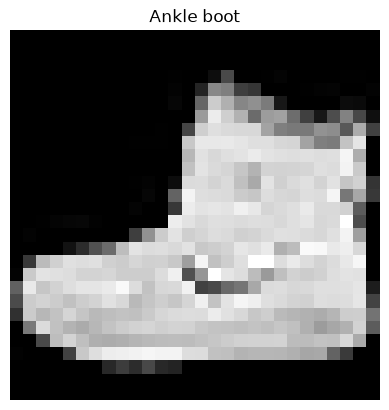

In [ ]:
#pobiera pierwszy obraz ze zbioru treningowego, pokaż go w skali szarości (rysowanie)
plt.imshow(X_train[0], cmap="gray")
#tytuł wykresu
plt.title(class_names[y_train[0]])
#wyłącza osie wykresu
plt.axis("off")
#Publikacja
plt.show()

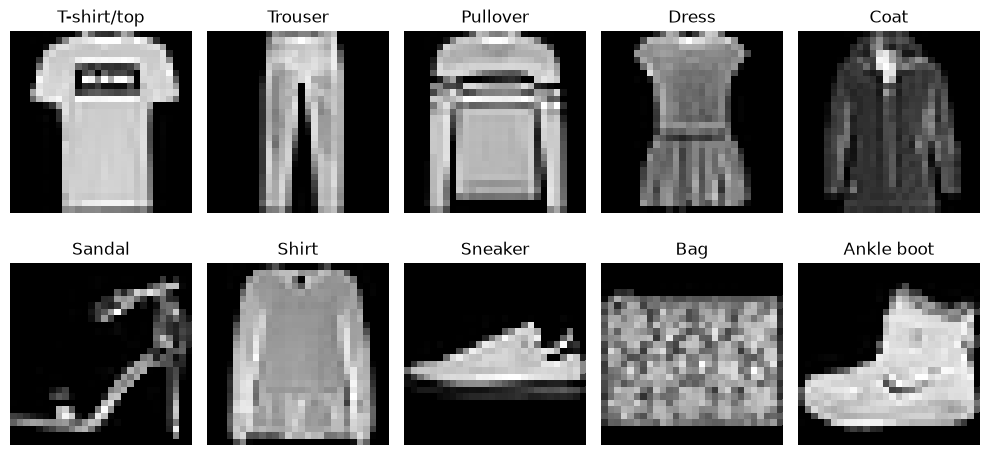

In [10]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,5))

for label in range(10):
    idx = np.where(y_train == label)[0][0]

    plt.subplot(2,5,label+1)
    plt.imshow(X_train[idx], cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()

plt.savefig("klasy_fashion_mnist.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# Zakres wartości pikseli

In [6]:
print("Minimalna wartość piksela:", X_train.min())
print("Maksymalna wartość piksela:", X_train.max())

Minimalna wartość piksela: 0
Maksymalna wartość piksela: 255


# Czy zbiór zawiera brakujące dane

In [12]:
import numpy as np

print(np.isnan(X_train).sum())
print(np.isnan(X_test).sum())

0
0


# Rozkład klas

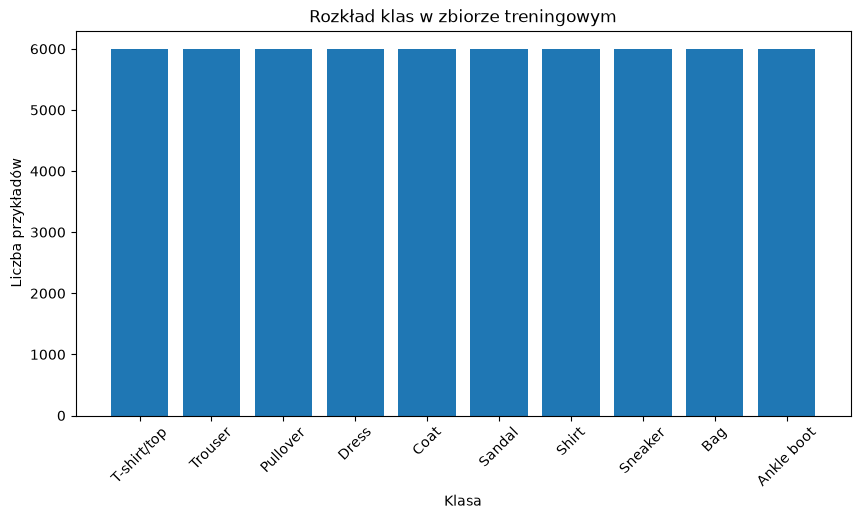

In [7]:
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10, 5))
plt.bar([class_names[i] for i in unique], counts)
plt.xticks(rotation=45)
plt.title("Rozkład klas w zbiorze treningowym")
plt.xlabel("Klasa")
plt.ylabel("Liczba przykładów")
plt.show()

#Jak wygląda średni obraz z klasy (przykład na podstawie klasy T-shirt)

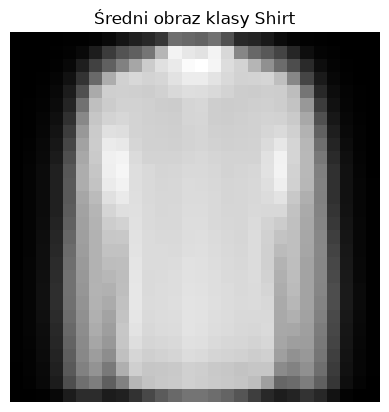

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#idx = np.where(y_train == 0)
#idx = np.where(y_train == 4)
idx = np.where(y_train == 6)

mean_image = X_train[idx].mean(axis=0)

plt.imshow(mean_image, cmap="gray")
plt.title("Średni obraz klasy Shirt")
plt.axis("off")
plt.show()

Zbiór Fashion-MNIST zawiera obrazy ubrań w skali szarości o wymiarach 28×28 pikseli. 
Dane są podzielone na 60 000 przykładów treningowych oraz 10 000 przykładów testowych. Wydzielenie zbioru walidacyjnego zostanie wykonane w II części projektu.

Każdy obraz należy do jednej z 10 klas, takich jak koszulka, spodnie, sukienka, but, torba lub płaszcz. 
Wartości pikseli mieszczą się w zakresie od 0 do 255. Nie występują braki w danych.

Na podstawie rozkładu klas można zauważyć, że zbiór jest zbalansowany, ponieważ każda klasa ma podobną liczbę przykładów.